## 6. Deployment

What runs where, and what has and hasn't been deployed:

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

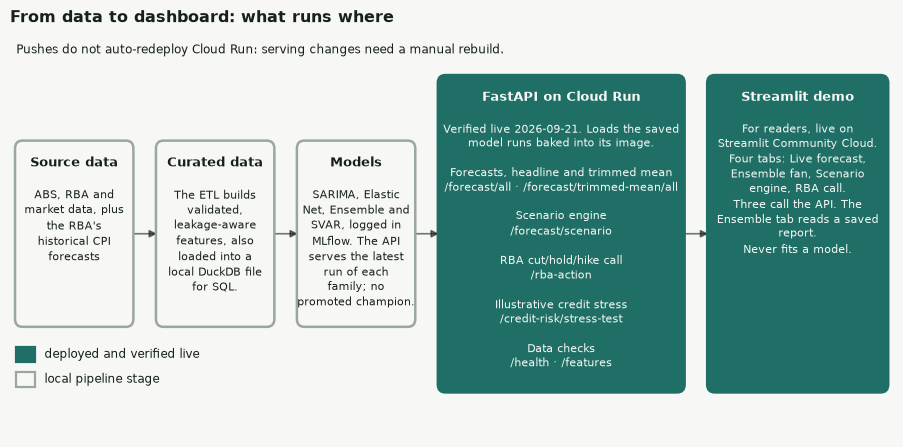

In [2]:
import textwrap
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.set_xlim(0, 14.1)
ax.set_ylim(0, 6.2)
ax.axis("off")

def box(x, y, w, h, title, body, kind, wrap=22, size=8.2):
    style = {"live": dict(fc=ACCENT, ec=ACCENT, tc=PAPER, hatch=None),
             "local": dict(fc=PAPER, ec=HIGHLIGHT, tc=INK, hatch=None),
             "pipe": dict(fc=PAPER, ec=MUTED, tc=INK, hatch=None)}[kind]
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12", facecolor=style["fc"],
                                edgecolor=style["ec"], linewidth=1.8, zorder=2))
    ax.text(x + w / 2, y + h - 0.22, title, ha="center", va="top", fontsize=9.5, fontweight="bold", color=style["tc"], zorder=3)
    ax.text(x + w / 2, y + h - 0.68, "\n".join(textwrap.fill(p, wrap, break_on_hyphens=False) for p in body.split("\n")),
            ha="center", va="top", fontsize=size, color=style["tc"], zorder=3, linespacing=1.35)

def arrow(x0, x1, y=3.1):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), zorder=1,
                arrowprops=dict(arrowstyle="-|>", color=INK, alpha=0.6, lw=1.2, shrinkA=0, shrinkB=0))

# layout: three narrow pipeline boxes, then the two deployed boxes, which carry more text
gap, w_pipe = 0.4, 1.85
xs = [0.1 + i * (w_pipe + gap) for i in range(3)]
x_api, w_api = xs[2] + w_pipe + gap, 3.9
x_app, w_app = x_api + w_api + gap, 2.85

box(xs[0], 1.7, w_pipe, 2.8, "Source data", "ABS, RBA and market data, plus the RBA's historical CPI forecasts", "pipe", wrap=18)
box(xs[1], 1.7, w_pipe, 2.8, "Curated data", "The ETL builds validated, leakage-aware features, also loaded into a local DuckDB file for SQL.", "pipe", wrap=18)
box(xs[2], 1.7, w_pipe, 2.8, "Models",
    "SARIMA, Elastic Net, Ensemble and SVAR, logged in MLflow. The API serves the latest run of each family; no promoted champion.",
    "pipe", wrap=18)
for i in range(2):
    arrow(xs[i] + w_pipe, xs[i + 1])
arrow(xs[2] + w_pipe, x_api)

# FastAPI on Cloud Run: what each route is for
box(x_api, 0.7, w_api, 4.8, "FastAPI on Cloud Run",
    "Verified live 2026-09-21. Loads the saved model runs baked into its image.\n"
    "\nForecasts, headline and trimmed mean\n/forecast/all \u00b7 /forecast/trimmed-mean/all\n"
    "\nScenario engine\n/forecast/scenario\n"
    "\nRBA cut/hold/hike call\n/rba-action\n"
    "\nIllustrative credit stress\n/credit-risk/stress-test\n"
    "\nData checks\n/health \u00b7 /features",
    "live", wrap=44, size=7.8)
arrow(x_api + w_api, x_app)
box(x_app, 0.7, w_app, 4.8, "Streamlit demo",
    "For readers, live on Streamlit Community Cloud.\nFour tabs: Live forecast, Ensemble fan, Scenario engine, RBA call.\n"
    "Three call the API. The Ensemble tab reads a saved report.\nNever fits a model.",
    "live", wrap=28, size=8)

# legend
lx, ly = 0.1, 1.15
for i, (fc, ec, text) in enumerate([(ACCENT, ACCENT, "deployed and verified live"),
                                    (PAPER, MUTED, "local pipeline stage")]):
    ax.add_patch(plt.Rectangle((lx, ly - 0.38 * i), 0.3, 0.22, facecolor=fc, edgecolor=ec, linewidth=1.6))
    ax.text(lx + 0.45, ly - 0.38 * i + 0.11, text, va="center", fontsize=8.3)
ax.text(0.1, 5.85, "Pushes do not auto-redeploy Cloud Run: serving changes need a manual rebuild.", fontsize=8.5)
ax.set_title("From data to dashboard: what runs where", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

- **FastAPI on Cloud Run:** redeployed and verified live 2026-09-21, serving
  `/forecast/all`, `/forecast/trimmed-mean/all`, `/forecast/scenario`, `GET /rba-action`
  and `GET /credit-risk/stress-test` from baked local MLflow runs. Pushes do not
  auto-redeploy; manual rebuild required after serving changes. The Dockerfile now installs
  with `constraints.txt`; the live image was built before that, so its package versions were
  not pinned. A rebuild from this repo uses the pinned versions.
- **Same models, slightly different simulations:** point forecasts and intervals agree with a
  local run to within 2e-9, and the credit stress test to within 1e-11. The simulation-heavy
  outputs differ a little: on 2026-09-22 the scenario forecast was off by up to 0.031 pp and the
  RBA probabilities by up to 0.2 pp, and no RBA action changed. Asked the same questions twice,
  Cloud Run returned identical answers, so the gap is not randomness. Forcing a different CPU kernel
  on a local machine gave the same kind of shift, so different arithmetic is a likely cause, but
  the live image was also built from unpinned packages, so hardware is not the only difference.
  The chart in the Reproducibility section below has the numbers.
- **Streamlit:** a four-tab interactive demo (Live forecast, 4.3 Ensemble, 4.5 Scenario
  Engine, 4.6 RBA Policy Classifier), hosted on Streamlit Community Cloud at <https://cpi-forecast-demo.streamlit.app/> and
  verified live 2026-09-21. Three tabs call the Cloud Run API and the Ensemble tab reads a
  committed report; none fit models in-process. The hosted copy is locked to the Cloud Run
  API, so visitors cannot point it at another address.
- **No MLflow champion/registry promotion:** `/forecast/all` serves every family's latest
  finished run directly; there is no promoted "best" model.

### Reproducibility: what you can rely on

Every number in this book comes from a fixed data snapshot, a pinned forecast origin and seeded simulations. The chain below shows what holds each step in place. The numbered boxes underneath are where results can still differ, and the notes after the diagram explain each one.

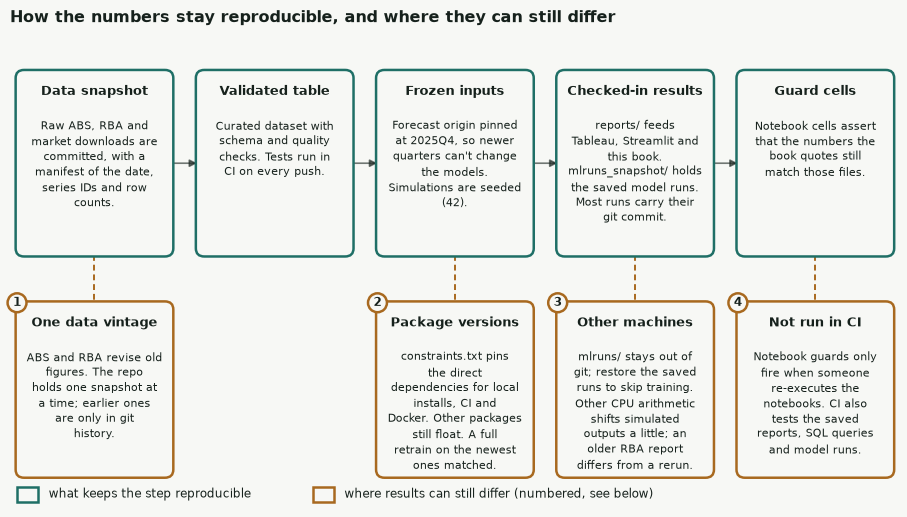

In [ ]:
import textwrap
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9.2, 5.3))
ax.set_xlim(0, 12.6)
ax.set_ylim(0, 7.0)
ax.axis("off")

def box(x, y, w, h, title, body, edge, wrap=22, size=8.2):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12", facecolor=PAPER,
                                edgecolor=edge, linewidth=1.8, zorder=2))
    ax.text(x + w / 2, y + h - 0.2, title, ha="center", va="top", fontsize=9.3, fontweight="bold", color=INK, zorder=3)
    ax.text(x + w / 2, y + h - 0.68, "\n".join(textwrap.fill(p, wrap, break_on_hyphens=False) for p in body.split("\n")),
            ha="center", va="top", fontsize=size, color=INK, zorder=3, linespacing=1.35)

stages = [
    ("Data snapshot", "Raw ABS, RBA and market downloads are committed, with a manifest of the date, series IDs and row counts."),
    ("Validated table", "Curated dataset with schema and quality checks. Tests run in CI on every push."),
    ("Frozen inputs", "Forecast origin pinned at 2025Q4, so newer quarters can't change the models. Simulations are seeded (42)."),
    ("Checked-in results", "reports/ feeds Tableau, Streamlit and this book. mlruns_snapshot/ holds the saved model runs. Most runs carry their git commit."),
    ("Guard cells", "Notebook cells assert that the numbers the book quotes still match those files."),
]
hazards = {
    0: ("One data vintage", "ABS and RBA revise old figures. The repo holds one snapshot at a time; earlier ones are only in git history."),
    2: ("Package versions", "constraints.txt pins the direct dependencies for local installs, CI and Docker. Other packages still float. A full retrain on the newest ones matched."),
    3: ("Other machines", "mlruns/ stays out of git; restore the saved runs to skip training. Other CPU arithmetic shifts simulated outputs a little; an older RBA report differs from a rerun."),
    4: ("Not run in CI", "Notebook guards only fire when someone re-executes the notebooks. CI also tests the saved reports, SQL queries and model runs."),
}
x0, w, gap = 0.1, 2.2, 0.36
n = 1
for i, (title, body) in enumerate(stages):
    x = x0 + i * (w + gap)
    box(x, 3.7, w, 2.7, title, body, ACCENT)
    if i:
        ax.annotate("", xy=(x, 5.05), xytext=(x - gap, 5.05), zorder=1,
                    arrowprops=dict(arrowstyle="-|>", color=INK, alpha=0.6, lw=1.2, shrinkA=0, shrinkB=0))
    if i in hazards:
        ax.plot([x + w / 2, x + w / 2], [3.7, 3.0], color=HIGHLIGHT, linewidth=1.4, linestyle=(0, (3, 2)), zorder=1)
        box(x, 0.45, w, 2.55, *hazards[i], HIGHLIGHT)
        ax.text(x, 3.0, str(n), ha="center", va="center", fontsize=8.5, fontweight="bold", color=INK, zorder=5,
                bbox=dict(boxstyle="circle,pad=0.3", facecolor=PAPER, edgecolor=HIGHLIGHT, linewidth=1.8))
        n += 1

for k, (edge, text) in enumerate([(ACCENT, "what keeps the step reproducible"), (HIGHLIGHT, "where results can still differ (numbered, see below)")]):
    ax.add_patch(plt.Rectangle((0.1 + 4.2 * k, 0.08), 0.3, 0.22, facecolor=PAPER, edgecolor=edge, linewidth=1.8))
    ax.text(0.55 + 4.2 * k, 0.19, text, va="center", fontsize=8.3)
ax.set_title("How the numbers stay reproducible, and where they can still differ", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()


Each numbered box in the diagram is a place where a rerun can drift. The chart further down is drawn from real comparisons, saved in `reports/reproducibility_check.csv` (`python -m src.reproducibility_check` builds it), so what follows says what each box means and how far things actually moved.

#### 1. One data vintage

ABS and RBA quietly revise old figures, so the same series holds different numbers on different days. Between the downloads of 2026-08-24 and 2026-09-03 (UTC, from the download manifest), 161 of household spending's 162 monthly values changed, by up to 0.235%. Every model trains on these numbers, so a fresh download changes the inputs of everything downstream. We haven't measured how far the forecasts move as a result. That's why the repo keeps one frozen snapshot, and why the README says not to run `data_retrieval.py`.

#### 2. Package versions

The models are fitted by numerical routines in pandas, statsmodels, scikit-learn and numpy, and a new release can change how those routines round or where their searches stop. `constraints.txt` pins the direct dependencies so local installs, CI and Docker agree, but the packages they pull in can still float. To see whether it matters, we retrained every model from scratch with the newest packages and compared the 44 files the run rewrote with the saved ones. 43 were byte-identical. The other is `dataset_overview.csv`, which differs only in the date the data was last written, and no number changed in any of the 89,322 table cells. So pinning is insurance here, not a fix for a problem we saw.

:::{dropdown} How the retrain was set up
The retrain ran in a fresh environment with the newest packages (pandas 3.0.6 instead of 2.3.3, statsmodels 0.15.0 instead of 0.14.6, scikit-learn 1.9.1 instead of 1.9.0; numpy and scipy were the same versions in both). The four interval coverage and calibration reports take about 90 minutes and weren't part of that run.
:::

#### 3. Other machines

We can't run a second computer here, so we imitated one by forcing the maths library (OpenBLAS) onto a different CPU kernel, and by limiting it to one thread. Cloud Run is a real other machine.

- *Simulated outputs move a little; forecasts hardly move.* Cloud Run's point forecasts and intervals agree with a local run to within 2e-9, but its scenario forecast is off by up to 0.031 pp and its RBA probabilities by up to 0.2 pp. No RBA action changed. Asked the same questions twice, Cloud Run gave identical answers, so the gap isn't randomness. Forcing the Sandy Bridge kernel on this machine gives the same kind of shift (forecasts within 2e-10, scenario forecast up to 0.019 pp, RBA probabilities up to 0.5 pp), while limiting it to one thread changed none of 315 numbers. So different arithmetic is enough to produce a gap of this size. That doesn't prove it's what happens on Cloud Run, whose image was also built from unpinned packages.
- *The RBA classifier's early fits are unstable, but CPU arithmetic didn't change its calls.* Its first fold trains on only 12 quarters and the report flags 2 of 82 ordered-model fits as unstable. An earlier committed version of the report, made in an environment that wasn't recorded, differs from a rerun in 4 of 82 ordered-model calls (the ordered logit in 2022Q2 and 2023Q4, the ordered probit in 2016Q4 and 2023Q4). The report's inputs and prediction code haven't changed since then, so the difference isn't in what the classifier was given, but what caused it isn't known. Forcing three other CPU kernels didn't flip any of 861 calls and moved the ordered models' probabilities by less than 3e-9, so CPU arithmetic isn't the explanation. It did move the ordered logit's unstable first-fold cut-offs by up to 25, and the simulation-based threshold model's probabilities by up to 4.7 pp. The report itself advises treating the classifier scores as reproducible within one environment.

#### 4. Guards that CI doesn't run

The guard cells that check the numbers quoted in the prose only fire when someone re-executes a notebook, so a stale number could sit in the text until then. CI covers the saved reports, SQL queries and model runs instead, and `tests/test_book_report_contracts.py` checks the report headings and columns that sections 4.3 and 4.6 read.

The chart below puts the comparisons on one scale, from "the same results" to "the inputs themselves differ".

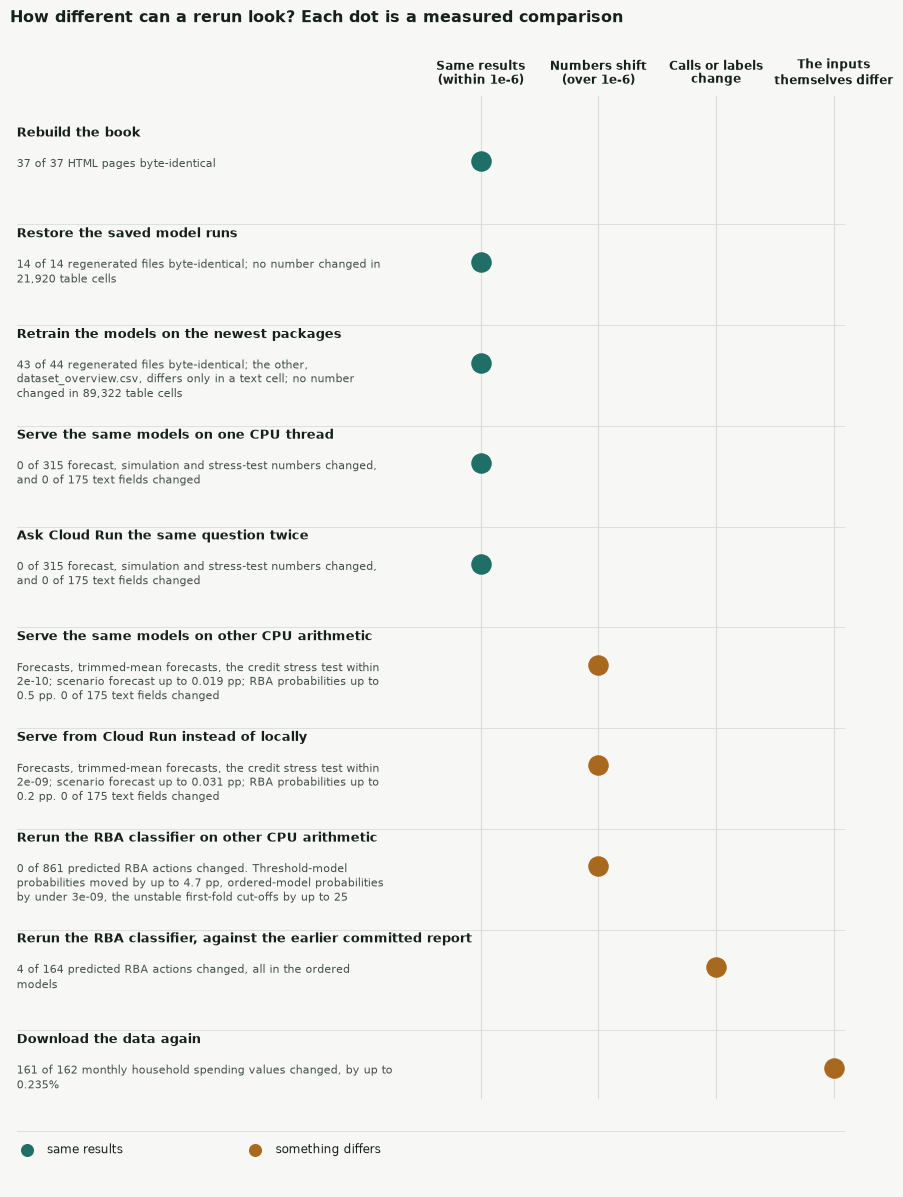

In [ ]:
import math
import textwrap
from pathlib import Path

CHECK = pd.read_csv(PROJECT_ROOT / "reports" / "reproducibility_check.csv")
DETAIL = pd.read_csv(PROJECT_ROOT / "reports" / "reproducibility_check_files.csv")
SOFT_INK = "#44504a"
TOL = 1e-6  # differences at or below this count as the same number


def up(x, sig=2):
    """Round UP to `sig` significant figures, so every 'within X' and 'up to X' in the notes is true."""
    if x == 0:
        return 0.0
    e = math.floor(math.log10(abs(x))) - (sig - 1)
    return math.ceil(x / 10**e - 1e-9) * 10**e


def rows_for(sid):
    return CHECK[CHECK["scenario_id"] == sid]


def column_for(sid):
    """0 same results, 1 numbers shift, 2 calls or labels change, 3 the inputs differ. Read off the measurements."""
    d = rows_for(sid)
    if (d["unit"].eq("values") & d["n_changed"].gt(0)).any():
        return 3
    if (d["unit"].isin(["labels", "calls"]) & d["n_changed"].gt(0)).any():
        return 2
    odd = DETAIL[(DETAIL["scenario_id"] == sid) & ~DETAIL["byte_identical"] & DETAIL["cells_compared"].eq(0)]
    if len(odd):
        raise ValueError(f"{sid}: a file that is not a table differs ({odd['file'].tolist()}); extend the rule")
    numbers = d[~d["unit"].isin(["files", "labels", "calls"])]
    return 1 if numbers["max_abs_diff"].max() > TOL else 0


SHORT = {
    "point forecasts and intervals: forecast and interval numbers": "forecasts",
    "trimmed-mean forecasts and intervals: forecast and interval numbers": "trimmed-mean forecasts",
    "credit stress test: numbers": "the credit stress test",
    "scenario forecast (simulated): forecast and interval numbers": "scenario forecast",
    "RBA action readings (simulated): probabilities": "RBA probabilities",
    "RBA action readings (simulated): forecasts": "RBA forecast inputs",
}


def note_for(sid):
    d = rows_for(sid)
    by = {r["quantity"]: r for _, r in d.iterrows()}
    files = by.get("files regenerated")
    if files is not None:
        n = int(files["n_compared"])
        text = f"{n - int(files['n_changed'])} of {n} {'HTML pages' if sid == 'book_rebuild' else 'regenerated files'} byte-identical"
        bad = DETAIL[(DETAIL["scenario_id"] == sid) & ~DETAIL["byte_identical"]]
        if len(bad):
            text += f"; {'the other' if len(bad) == 1 else 'the others'}, {', '.join(Path(f).name for f in bad['file'])}, {'differs' if len(bad) == 1 else 'differ'} only in a text cell"
        cells = by.get("table cells")
        if cells is not None:
            text += (f"; no number changed in {int(cells['n_compared']):,} table cells" if cells["max_abs_diff"] == 0
                     else f"; numbers changed by up to {up(cells['max_abs_diff']):.0e}")
        return text
    calls = d[d["unit"].eq("calls")]
    if len(calls):
        r = calls.iloc[0]
        ordered = by["RBA classifier calls, ordered logit and probit"]
        text = f"{int(r['n_changed'])} of {int(r['n_compared']):,} predicted RBA actions changed"
        if r["n_changed"] and r["n_changed"] == ordered["n_changed"]:
            text += ", all in the ordered models"
        thr = by.get("RBA classifier probabilities, threshold model (simulated)")
        if thr is not None:
            text += f". Threshold-model probabilities moved by up to {up(thr['max_abs_diff'] * 100):g} pp"
            text += f", ordered-model probabilities by under {up(by['RBA classifier probabilities, ordered logit and probit']['max_abs_diff'], 1):.0e}"
        cut = by.get("ordered logit cut-offs, first fold vs last")
        if cut is not None:
            text += f", the unstable first-fold cut-offs by up to {up(cut['max_abs_diff'], 2):g}"
        return text
    if d["unit"].eq("values").any():
        v = d[d["unit"].eq("values")].iloc[0]
        rel = d[d["unit"].eq("share")].iloc[0]
        return f"{int(v['n_changed'])} of {int(v['n_compared'])} monthly household spending values changed, by up to {up(rel['max_abs_diff'] * 100, 3):g}%"
    nums = d[~d["unit"].isin(["labels"])]
    lab = d[d["unit"].eq("labels")]
    lab_text = f"{int(lab['n_changed'].sum())} of {int(lab['n_compared'].sum())} text fields changed"
    if nums["n_changed"].sum() == 0:
        return f"0 of {int(nums['n_compared'].sum())} forecast, simulation and stress-test numbers changed, and {lab_text}"
    tiny = nums[nums["n_changed"].gt(0) & nums["max_abs_diff"].le(TOL)]
    big = nums[nums["max_abs_diff"].gt(TOL)]
    parts = []
    if len(tiny):
        names = dict.fromkeys(SHORT[q] for q in tiny["quantity"] if q in SHORT)
        parts.append(f"{', '.join(names)} within {up(tiny['max_abs_diff'].max(), 1):.0e}")
    for _, r in big.iterrows():
        scale = 100 if r["unit"] == "probability" else 1
        parts.append(f"{SHORT.get(r['quantity'], 'other numbers')} up to {up(r['max_abs_diff'] * scale):g} pp")
    text = "; ".join(parts) + f". {lab_text}"
    return text[0].upper() + text[1:]


ORDER = ["book_rebuild", "restore", "retrain_new", "one_thread", "cloud_run_repeat", "other_cpu", "cloud_run",
         "classifier_cpu", "classifier_env", "new_data"]
assert sorted(ORDER) == sorted(set(CHECK["scenario_id"])), "the chart and reports/reproducibility_check.csv list different scenarios"
rows = sorted((column_for(s), k, s) for k, s in enumerate(ORDER))  # by column, then the order above
cols = ["Same results\n(within 1e-6)", "Numbers shift\n(over 1e-6)", "Calls or labels\nchange", "The inputs\nthemselves differ"]

n_rows = len(rows)
fig, ax = plt.subplots(figsize=(9.2, 1.08 * n_rows + 1.3))
step, top = 1.08, 1.08 * n_rows + 0.55
ax.set_xlim(0, 12.6)
ax.set_ylim(0, top + 1.05)
ax.axis("off")
col_x = [7.0 + 1.75 * i for i in range(4)]

for cx, label in zip(col_x, cols):
    ax.text(cx, top + 0.45, label, ha="center", va="bottom", fontsize=8.3, fontweight="bold", color=INK, linespacing=1.25)
    ax.plot([cx, cx], [0.95, top + 0.35], color=GRID, linewidth=0.8, zorder=0)

for k, (col, _, sid) in enumerate(rows):
    y = top - 0.35 - k * step
    name = rows_for(sid)["scenario"].iloc[0]
    ax.plot([0.1, 12.4], [y - 0.68, y - 0.68], color=GRID, linewidth=0.6, zorder=0)
    ax.text(0.1, y + 0.3, name, ha="left", va="center", fontsize=9.2, fontweight="bold", color=INK)
    ax.text(0.1, y + 0.05, textwrap.fill(note_for(sid), 64), ha="left", va="top", fontsize=7.9, color=SOFT_INK, linespacing=1.3)
    ax.scatter([col_x[col]], [y], s=190, color=ACCENT if col == 0 else HIGHLIGHT, zorder=3)

for k, (colour, text) in enumerate([(ACCENT, "same results"), (HIGHLIGHT, "something differs")]):
    ax.scatter([0.25 + 3.4 * k], [0.4], s=70, color=colour)
    ax.text(0.55 + 3.4 * k, 0.4, text, va="center", fontsize=8.3)
ax.set_title("How different can a rerun look? Each dot is a measured comparison", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

**How to read the chart.** Nothing on it is placed by hand. Each row's dot and note are computed from `reports/reproducibility_check.csv`, and a dot's column follows a fixed rule: if the inputs differ, it goes in the last column; otherwise, if any predicted RBA action or text label changed, the third; otherwise, if any number moved by more than 1e-6, the second; otherwise the first. Every "within" and "up to" in the notes is rounded up, so it is never smaller than the measured value. The `how` column of that file records the recipe for each row. The comparisons ran on one Linux machine under WSL2, and only the Cloud Run rows involve another machine. "Other CPU arithmetic" means OpenBLAS forced onto another kernel. "Rebuild the book" checks that the build is repeatable; the notebooks themselves are not re-executed by a build.

In [ ]:
# Guard: every number quoted in the chapter's reproducibility text must match the recorded measurements
import re

def m(sid, quantity):
    row = CHECK[(CHECK["scenario_id"] == sid) & (CHECK["quantity"] == quantity)]
    assert len(row) == 1, (sid, quantity)
    return row.iloc[0]

def worst(sid, *quantities):
    return max(m(sid, q)["max_abs_diff"] for q in quantities)

FC = "point forecasts and intervals: forecast and interval numbers"
TM = "trimmed-mean forecasts and intervals: forecast and interval numbers"
CREDIT = "credit stress test: numbers"
SCEN = "scenario forecast (simulated): forecast and interval numbers"
RBA = "RBA action readings (simulated): probabilities"

v = m("new_data", "household_spending monthly values")
assert (v["n_changed"], v["n_compared"]) == (161, 162)
rel = m("new_data", "household_spending monthly values, relative")["max_abs_diff"] * 100
assert rel <= 0.235 < rel + 0.001

r = m("retrain_new", "files regenerated")
assert (r["n_compared"], r["n_changed"]) == (44, 1)
assert m("retrain_new", "table cells")["n_compared"] == 89322 and m("retrain_new", "table cells")["max_abs_diff"] == 0
retrain = DETAIL[DETAIL["scenario_id"] == "retrain_new"]
assert retrain[~retrain["byte_identical"]]["file"].tolist() == ["reports/tableau/dataset_overview.csv"]
assert retrain[retrain["file"].str.contains("simulation_fan")]["byte_identical"].all()
assert m("book_rebuild", "files regenerated")[["n_compared", "n_changed"]].tolist() == [37, 0]
assert m("restore", "files regenerated")[["n_compared", "n_changed"]].tolist() == [14, 0]

assert worst("cloud_run", FC, TM) <= 2e-9 and worst("cloud_run", CREDIT) <= 1e-11
assert 0.030 < worst("cloud_run", SCEN) <= 0.031
assert worst("cloud_run", RBA) == 0.002
assert worst("other_cpu", FC, TM) <= 2e-10 and 0.018 < worst("other_cpu", SCEN) <= 0.019
assert worst("other_cpu", RBA) == 0.005
for sid in ("cloud_run", "other_cpu", "one_thread", "cloud_run_repeat"):
    assert CHECK[(CHECK["scenario_id"] == sid) & CHECK["unit"].eq("labels")]["n_changed"].sum() == 0, sid
for sid in ("one_thread", "cloud_run_repeat"):
    numbers = CHECK[(CHECK["scenario_id"] == sid) & ~CHECK["unit"].isin(["labels"])]
    assert numbers[["n_compared", "n_changed"]].sum().tolist() == [315, 0], sid

assert m("classifier_env", "RBA classifier calls, ordered logit and probit")[["n_compared", "n_changed"]].tolist() == [82, 4]
assert m("classifier_env", "RBA classifier calls, all models compared")["n_changed"] == 4
assert m("classifier_cpu", "RBA classifier calls, all models compared")[["n_compared", "n_changed"]].tolist() == [861, 0]
assert m("classifier_cpu", "RBA classifier probabilities, ordered logit and probit")["max_abs_diff"] < 3e-9
assert round(m("classifier_cpu", "RBA classifier probabilities, threshold model (simulated)")["max_abs_diff"] * 100, 1) == 4.7
assert 24 < m("classifier_cpu", "ordered logit cut-offs, first fold vs last")["max_abs_diff"] <= 25

report = (PROJECT_ROOT / "reports" / "rba_classifier_evaluation.md").read_text(encoding="utf-8")
assert "2 of 82 ordered-model fold fits" in report
assert re.search(r"\| ordered_logit\s*\| 2014Q1\s*\|\s*12\s*\|", report)

**In practice.** Reading or rebuilding this book gives identical pages, because its outputs are saved and it is not re-executed on build: two builds into empty folders matched on all 37 pages. Re-running the code on a fresh clone starts from the same data snapshot, so any difference comes from package versions, retraining or the machine. Installing with `pip install -r requirements.txt -c constraints.txt` (the file is in the project root) matches the versions the results were produced with. The seeded simulations then repeat exactly: the simulation fans regenerate byte for byte, and the [§4.3](04_modeling/43_ensemble) notebook re-checks the Ensemble fan every time it is run. To skip the roughly 45 minutes of training, restore the saved runs with `python -m src.mlruns_snapshot restore`; the regenerated Tableau exports, `forecast.csv` included, then match the saved ones byte for byte (14 of 14 files). The step-by-step recipe, with the commands and what each check should show, is in the README's [Reproduce the results](https://github.com/JuanVu1810/CPI-Forecast#reproduce-the-results) section, which also records an earlier hand-run check that included the four interval reports.